In [28]:
import pandas as pd
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import nltk
from sklearn.decomposition import NMF
import numpy as np
from nltk.corpus import stopwords
import spacy
from gensim.corpora import Dictionary
from gensim.models import LdaModel

## LDA 

In [29]:
# Path 
path = Path("../data/raw/text_files/1993/legislatives")
documents = []

# To get all .txt files in the folder and read their content
for file in path.glob("*.txt"):
    try:
        texte = file.read_text(encoding='utf-8', errors='ignore')
        documents.append({
            "filename": file.name,
            "texte_brut": texte})
    except Exception as e:
        print(f"Error with {file.name} : {e}")


df = pd.DataFrame(documents)
print(f"{len(df)} documents in the dataframe")

5936 documents in the dataframe


In [30]:
import pandas as pd

print(f"Tableau d'origine : {len(df)} documents complets.")

# 1. Découpage par sauts de ligne
# On utilise une expression régulière (r'\n+') pour couper le texte à chaque fois 
# qu'il y a un ou plusieurs sauts de ligne. Cela crée une liste de paragraphes.
df['liste_paragraphes'] = df['texte_brut'].str.split(r'\n+')

# 2. L'explosion du DataFrame (La magie de Pandas)
# La fonction explode() va prendre chaque paragraphe de la liste et créer une 
# nouvelle ligne dans le tableau, tout en dupliquant le 'filename' correspondant !
df_para = df.explode('liste_paragraphes').reset_index(drop=True)

# 3. On renomme la colonne pour que ce soit propre
df_para = df_para.rename(columns={'liste_paragraphes': 'paragraphe_brut'})

# 4. Le filtre anti-bruit (Crucial pour l'OCR)
# L'OCR génère souvent des "paragraphes" qui ne sont qu'un chiffre, un tiret 
# ou un mot coupé. On va éliminer tous les paragraphes de moins de 50 caractères.
df_para['paragraphe_brut'] = df_para['paragraphe_brut'].astype(str) # Sécurité
df_para = df_para[df_para['paragraphe_brut'].str.len() > 50].reset_index(drop=True)

print(f"Nouveau tableau : {len(df_para)} paragraphes robustes extraits !")
print("\n--- Aperçu des premiers paragraphes du premier fichier ---")
print(df_para[['filename', 'paragraphe_brut']].head(3))

Tableau d'origine : 5936 documents complets.
Nouveau tableau : 134600 paragraphes robustes extraits !

--- Aperçu des premiers paragraphes du premier fichier ---
                             filename  \
0  EL190_L_1993_03_016_02_2_PF_02.txt   
1  EL190_L_1993_03_016_02_2_PF_02.txt   
2  EL190_L_1993_03_016_02_2_PF_02.txt   

                                     paragraphe_brut  
0  République Française - Département de la Chare...  
1  JEAN-CLAUDE FAYEMENDIE Conseiller Municipal de...  
2  Alliance des Français pour le ProgrèsSciences ...  


In [31]:
import spacy
from gensim.corpora import Dictionary
from gensim.models import LdaModel
import numpy as np

# --- ÉTAPE 1 : Nettoyage ultra-rapide par lots (Batch processing) ---
# On charge spaCy sans les fonctions lourdes
nlp = spacy.load("fr_core_news_sm", disable=["ner", "parser"])

# On s'assure d'avoir notre liste de mots parasites
mots_parasites = {"candidat", "élection", "république", "français", "madame", "monsieur", "plus", "tout", "faire", "dire"}

print(f"Nettoyage de {len(df_para)} paragraphes en cours... (Patientez quelques minutes)")

# nlp.pipe() est la clé : il traite les textes par paquets de 1000, ce qui divise le temps par 10 !
textes_bruts = df_para['paragraphe_brut'].tolist()
mots_propres_list = []

for doc in nlp.pipe(textes_bruts, batch_size=1000):
    mots = [
        token.lemma_ for token in doc 
        if not token.is_punct and not token.is_space and not token.like_num 
        and not token.is_stop and len(token.lemma_) > 2 
        and token.lemma_ not in mots_parasites
    ]
    mots_propres_list.append(mots)

df_para['mots_propres'] = mots_propres_list

# Filtre de sécurité : on supprime les paragraphes qui se retrouvent vides après le nettoyage
df_para = df_para[df_para['mots_propres'].map(len) > 3].reset_index(drop=True)
print(f"Nettoyage terminé. {len(df_para)} paragraphes solides conservés.")

# --- ÉTAPE 2 : Modélisation LDA sur les paragraphes ---
textes_tokenises = df_para['mots_propres'].tolist()

dictionnaire = Dictionary(textes_tokenises)
# Note : On abaisse no_above à 0.5. Si un mot apparaît dans plus de 50% des paragraphes, c'est du bruit.
dictionnaire.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionnaire.doc2bow(texte) for texte in textes_tokenises]

print("\nEntraînement du modèle LDA en cours...")
nombre_de_themes = 15 # 15 thèmes donne assez d'espace pour isoler l'économie

lda_para = LdaModel(
    corpus=corpus,
    id2word=dictionnaire,
    num_topics=nombre_de_themes,
    random_state=42,
    passes=5 # 5 passages suffisent généralement pour des paragraphes
)

print("\n--- Les thèmes extraits ---")
for idx, topic in lda_para.print_topics(num_words=8):
    print(f"Thème {idx} : {topic}")


# --- ÉTAPE 3 : Agrégation (Reconstruire le document pour l'INSEE) ---
# 3a. Fonction pour trouver le thème numéro 1 de chaque paragraphe
def obtenir_theme_dominant(bow):
    if not bow: return -1
    topics = lda_para.get_document_topics(bow)
    return max(topics, key=lambda item: item[1])[0]

# On applique le thème à chaque ligne
df_para['theme_dominant'] = [obtenir_theme_dominant(bow) for bow in corpus]

# 3b. La magie de Pandas : Le tableau croisé pour avoir les % par document
# On compte combien de paragraphes de chaque thème il y a dans chaque fichier
theme_comptage = df_para.groupby(['filename', 'theme_dominant']).size().unstack(fill_value=0)

# On divise par le total de paragraphes du document pour avoir un pourcentage de 0 à 1
theme_pourcentage = theme_comptage.div(theme_comptage.sum(axis=1), axis=0).reset_index()

print("\n--- Pourcentage d'espace dédié à chaque thème par profession de foi ---")
print(theme_pourcentage.head())

Nettoyage de 134600 paragraphes en cours... (Patientez quelques minutes)
Nettoyage terminé. 130876 paragraphes solides conservés.

Entraînement du modèle LDA en cours...

--- Les thèmes extraits ---
Thème 0 : 0.025*"chômage" + 0.022*"immigration" + 0.020*"corruption" + 0.019*"génération" + 0.018*"entente" + 0.018*"insécurité" + 0.018*"chance" + 0.017*"injustice"
Thème 1 : 0.028*"droite" + 0.026*"France" + 0.026*"politique" + 0.024*"vouloir" + 0.018*"gauche" + 0.018*"force" + 0.016*"être" + 0.016*"pays"
Thème 2 : 0.018*"élu" + 0.016*"rétablir" + 0.015*"travail" + 0.014*"RPR" + 0.014*"UDF" + 0.014*"aujourd'hui" + 0.014*"payer" + 0.013*"compte"
Thème 3 : 0.065*"circonscription" + 0.060*"mars" + 0.031*"législatif" + 0.026*"député" + 0.021*"confiance" + 0.017*"tour" + 0.017*"parti" + 0.017*"national"
Thème 4 : 0.022*"vote" + 0.019*"meilleur" + 0.019*"trouver" + 0.017*"donner" + 0.016*"délinquant" + 0.016*"monde" + 0.016*"nom" + 0.015*"bulletin"
Thème 5 : 0.087*"fonds" + 0.054*"cevipof" + 0.

In [32]:
# --- ÉTAPE 2 : Modélisation LDA Guidée sur les paragraphes ---
textes_tokenises = df_para['mots_propres'].tolist()

dictionnaire = Dictionary(textes_tokenises)
dictionnaire.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionnaire.doc2bow(texte) for texte in textes_tokenises]

nombre_de_themes = 15
taille_vocabulaire = len(dictionnaire)

# 1. Création de la matrice Eta (les a priori)
# On met un poids de base ultra-faible (0.001) pour laisser les autres thèmes libres
eta_matrix = np.full((nombre_de_themes, taille_vocabulaire), 0.001)

# 2. Tes mots-graines (ceux validés par Word2Vec + les classiques)
mots_graines = ['chômage', 'inégalité', 'mage', 'chô-', 'chomage', 'grandissant', 'chomâge', 'croissant', 'fléau', 'grave', 'aggraver', 'précarité', 'subir', 'délinquance', 'intolérance', 'déficit', 'conséquence', 'creuser', 'difficulté', 'remède', 'marginalisation']

# 3. Le Forcing (On frappe très fort avec un poids de 10 000)
poids_extreme = 10000.0 
mots_trouves = 0

for mot in mots_graines:
    if mot in dictionnaire.token2id:
        mot_id = dictionnaire.token2id[mot]
        eta_matrix[0, mot_id] = poids_extreme # On force TOUT sur le Thème 0
        mots_trouves += 1

print(f"\nMatrice Eta configurée : {mots_trouves} mots-graines trouvés et injectés dans le Thème 0.")
print("Entraînement du modèle LDA Guidé en cours...")

# 4. Entraînement avec le paramètre magique 'eta'
lda_para = LdaModel(
    corpus=corpus,
    id2word=dictionnaire,
    num_topics=nombre_de_themes,
    eta=eta_matrix, # <--- C'est ici que l'on force le modèle
    random_state=42,
    passes=5
)

print("\n--- Les thèmes extraits ---")
for idx, topic in lda_para.print_topics(num_words=8):
    print(f"Thème {idx} : {topic}")


Matrice Eta configurée : 21 mots-graines trouvés et injectés dans le Thème 0.
Entraînement du modèle LDA Guidé en cours...

--- Les thèmes extraits ---
Thème 0 : 0.049*"difficulté" + 0.048*"conséquence" + 0.048*"chômage" + 0.047*"inégalité" + 0.047*"déficit" + 0.047*"délinquance" + 0.047*"aggraver" + 0.047*"grave"
Thème 1 : 0.029*"droite" + 0.027*"France" + 0.026*"politique" + 0.023*"vouloir" + 0.019*"gauche" + 0.018*"force" + 0.016*"pays" + 0.016*"être"
Thème 2 : 0.018*"élu" + 0.017*"RPR" + 0.016*"UDF" + 0.016*"rétablir" + 0.015*"travail" + 0.013*"aujourd'hui" + 0.013*"payer" + 0.013*"compte"
Thème 3 : 0.052*"circonscription" + 0.048*"mars" + 0.024*"législatif" + 0.022*"député" + 0.017*"confiance" + 0.017*"national" + 0.015*"parti" + 0.014*"tour"
Thème 4 : 0.032*"immigration" + 0.031*"chômage" + 0.026*"fiscal" + 0.025*"corruption" + 0.023*"insécurité" + 0.019*"combattre" + 0.018*"vote" + 0.016*"meilleur"
Thème 5 : 0.084*"fonds" + 0.053*"cevipof" + 0.041*"die" + 0.039*"science" + 0.03

In [33]:
# stopwords 
nltk.download('stopwords', quiet=True)
french_stopwords = stopwords.words('french')

# words related to manifestos

# Parameters
vectorizer = TfidfVectorizer(
    stop_words=french_stopwords,
    max_df=0.95,     # too many documents (95%+) contain this word, so it's not discriminant
    min_df=5,        # ignore if the word appears in less than 5 documents
    max_features=5000 # number of words  to keep based on term frequency
)

# Application
X_tfidf = vectorizer.fit_transform(df['texte_brut'])
print(f"Matrice créée : {X_tfidf.shape[0]} documents, {X_tfidf.shape[1]} mots de vocabulaire.")

Matrice créée : 5936 documents, 5000 mots de vocabulaire.


In [34]:
topic_number = 15

lda_model = LatentDirichletAllocation(n_components=topic_number, random_state=42)
W = lda_model.fit_transform(X_tfidf) # Remplacez X_tfidf par votre matrice de comptage si possible

# Afficher les mots principaux pour chaque topic
mots_du_vocabulaire = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda_model.components_):
    print(f"\nTopic {topic_idx + 1} :")
    top_mots_idx = topic.argsort()[:-11:-1]
    top_mots = [mots_du_vocabulaire[i] for i in top_mots_idx]
    print(" | ".join(top_mots))


Topic 1 :
indépendants | lacaze | cr | union | jeannou | armée | concrétisation | éléctions | renoncer | divisions

Topic 2 :
patrons | die | payer | patronat | und | der | maintenir | travailleurs | leurs | devons

Topic 3 :
12 | refus | instauration | ans | maintien | humiliation | mise | mixte | assez | populaire

Topic 4 :
voulons | paris | rôle | mr | reformateurs | réformateurs | mouvement | détruire | système | rapports

Topic 5 :
di | corsica | ch | in | una | da | so | corse | révolutionnaire | suivant

Topic 6 :
animaux | nature | nouveaux | rassemblement | existence | marseille | activités | ecologistes | doivent | homme

Topic 7 :
entente | écologie | ecologistes | verts | ecologie | generation | écologistes | chance | peu | génération

Topic 8 :
naturelle | cevipov | loi | animaux | associations | cohérence | nature | parti | universaliste | bénévole

Topic 9 :
français | suppression | front | sauvons | mains | françaises | défense | allègement | suspension | apprentissag

In [35]:
# Most dominant topic for each document
df['theme_dominant'] = np.argmax(W, axis=1)
print(df[['filename', 'theme_dominant']].head(10))

                             filename  theme_dominant
0  EL190_L_1993_03_016_02_2_PF_02.txt              13
1  EL189_L_1993_03_003_02_1_PF_01.txt              13
2  EL193_L_1993_03_063_01_2_PF_01.txt              13
3  EL196_L_1993_03_076_12_1_PF_08.txt               5
4  EL190_L_1993_03_030_05_2_PF_01.txt              13
5  EL192_L_1993_03_051_04_2_PF_01.txt              13
6  EL192_L_1993_03_044_04_2_PF_01.txt              13
7  EL190_L_1993_03_022_02_1_PF_06.txt               5
8  EL198_L_1993_03_092_09_1_PF_03.txt              13
9  EL192_L_1993_03_056_03_1_PF_06.txt               5


## Guided LDA for analysis on unemployment

## BERTopic

In [36]:
from bertopic import BERTopic

In [37]:
print(f"Préparation de {len(df_para)} paragraphes pour BERTopic...")

# 1. Préparation des textes (BERTopic veut des chaînes de caractères, pas des listes)
def nettoyage_robuste(valeur):
    if isinstance(valeur, list):
        return " ".join(valeur)
    elif isinstance(valeur, str):
        return valeur.replace("[", "").replace("]", "").replace("'", "").replace(",", "")
    return ""

docs = df_para['mots_propres'].apply(nettoyage_robuste).tolist()

# 2. Configuration du Zero-Shot Topic Modeling
# Tu décris le thème exactement comme tu en parlerais à un humain
themes_cibles = [
    "chômage, emploi, précarité, licenciement et crise économique"
]

print("Chargement du modèle d'Intelligence Artificielle...")
topic_model = BERTopic(
    embedding_model="paraphrase-multilingual-MiniLM-L12-v2",
    zeroshot_topic_list=themes_cibles,
    zeroshot_min_similarity=0.80, # On baisse un tout petit peu la sévérité pour attraper plus de paragraphes
    language="french",
    verbose=True
)

# 3. Entraînement et Extraction
print("Entraînement en cours (création des embeddings, UMAP, HDBSCAN)...")
topics, probs = topic_model.fit_transform(docs)

# On injecte les résultats dans notre tableau de paragraphes
df_para['topic_bertopic'] = topics

# On affiche ce que le modèle a trouvé
print("\n--- Les thèmes extraits par BERTopic ---")
print(topic_model.get_topic_info().head(10))

# 4. AGRÉGATION : La reconstruction des professions de foi pour l'INSEE
print("\n--- Calcul du poids du chômage par profession de foi ---")

# On fait un tableau croisé dynamique : on compte combien de paragraphes de chaque thème il y a par fichier
theme_comptage = df_para.groupby(['filename', 'topic_bertopic']).size().unstack(fill_value=0)

# On divise par le nombre total de paragraphes du document pour obtenir un pourcentage
theme_pourcentage = theme_comptage.div(theme_comptage.sum(axis=1), axis=0).reset_index()

# Le thème que l'on a forcé s'appellera exactement par la chaîne de caractères qu'on a définie
# ou bien il prendra l'index 0. Affiche les colonnes pour vérifier son nom exact :
print("Aperçu des scores thématiques par document :")
print(theme_pourcentage.head())

2026-04-01 14:53:20,025 - BERTopic - Embedding - Transforming documents to embeddings.


Préparation de 130876 paragraphes pour BERTopic...
Chargement du modèle d'Intelligence Artificielle...
Entraînement en cours (création des embeddings, UMAP, HDBSCAN)...


Batches: 100%|██████████| 4090/4090 [03:15<00:00, 20.88it/s]
2026-04-01 14:56:40,526 - BERTopic - Embedding - Completed ✓
2026-04-01 14:56:40,526 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-01 14:59:10,015 - BERTopic - Dimensionality - Completed ✓
2026-04-01 14:59:10,018 - BERTopic - Zeroshot Step 1 - Finding documents that could be assigned to either one of the zero-shot topics
2026-04-01 14:59:10,347 - BERTopic - Zeroshot Step 1 - Completed ✓
2026-04-01 14:59:32,186 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-01 14:59:39,709 - BERTopic - Cluster - Completed ✓
2026-04-01 14:59:39,709 - BERTopic - Zeroshot Step 2 - Combining topics from zero-shot topic modeling with topics from clustering...
2026-04-01 14:59:39,894 - BERTopic - Zeroshot Step 2 - Completed ✓
2026-04-01 14:59:39,900 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-01 14:59:41,136 - BERTopic - Representation - Complete


--- Les thèmes extraits par BERTopic ---
   Topic  Count                                               Name  \
0     -1  52539                    -1_député_die_travailler_action   
1      0    339  chômage, emploi, précarité, licenciement et cr...   
2      1     18           1_rarement_propriétaire_simplement_ferme   
3      2     19                2_abroger_séjour_renouvelable_carte   
4      3     11                3_abroger_séjour_renouvelable_carte   
5      4     31                  4_accru_faible_exclure_protection   
6      5     25                 5_suspension_succession_ligne_7ièm   
7      6     32             6_sacrifier_demande_profit_travailleur   
8      7     18               7_maîtriser_croissance_mieux_pouvoir   
9      8     11               8_maîtriser_croissance_mieux_pouvoir   

                                      Representation  \
0  [député, die, travailler, action, local, conna...   
1  [nuit, phénomène, capitaliste, provoquer, gest...   
2  [rarement, propr

In [38]:
# On ne garde que la colonne "filename" et la colonne du "Topic 0"
df_insee = theme_pourcentage[['filename', 0]].copy()

# On renomme la colonne 0 pour que ce soit clair
df_insee = df_insee.rename(columns={0: 'score_chomage'})

print("--- TABLEAU FINAL PRÊT POUR L'INSEE ---")
print(df_insee.head(10))

# 1. On coupe le nom du fichier à chaque tiret du bas '_' et on récupère le 5ème morceau (index 4)
df_insee['code_departement'] = df_insee['filename'].str.split('_').str[4]

# 2. Le nettoyage pour l'INSEE
# Attention : Archelec écrit '016' pour la Charente, mais l'INSEE utilise souvent '16'.
# L'Archelec écrit '001' pour l'Ain, mais l'INSEE utilise '01'.
# On va créer une petite fonction pour formater ça parfaitement :
def formater_code_insee(code):
    code = str(code)
    # Si le code fait 3 caractères et commence par un 0 (ex: 016), on enlève le premier 0
    if len(code) == 3 and code.startswith('0'):
        return code[1:]
    return code

# On applique la correction
df_insee['code_departement'] = df_insee['code_departement'].apply(formater_code_insee)

# On réorganise les colonnes pour que ce soit beau
df_insee = df_insee[['filename', 'code_departement', 'score_chomage']]

print("--- TABLEAU FINAL PRÊT POUR LA JOINTURE ---")
print(df_insee.sort_values(by='score_chomage', ascending=False).head(10))

--- TABLEAU FINAL PRÊT POUR L'INSEE ---
topic_bertopic                                      filename  score_chomage
0               EL189_L_1993_03_001_01_1_BV_pdfmasterocr.txt       0.000000
1                         EL189_L_1993_03_001_01_1_PF_01.txt       0.000000
2                         EL189_L_1993_03_001_01_1_PF_02.txt       0.000000
3                         EL189_L_1993_03_001_01_1_PF_03.txt       0.000000
4                         EL189_L_1993_03_001_01_1_PF_04.txt       0.029412
5                         EL189_L_1993_03_001_01_1_PF_05.txt       0.000000
6                         EL189_L_1993_03_001_01_1_PF_06.txt       0.000000
7                         EL189_L_1993_03_001_01_1_PF_07.txt       0.000000
8                         EL189_L_1993_03_001_01_1_PF_08.txt       0.000000
9                         EL189_L_1993_03_001_01_2_PF_01.txt       0.000000
--- TABLEAU FINAL PRÊT POUR LA JOINTURE ---
topic_bertopic                            filename code_departement  \
804      

In [39]:
# On groupe par 'code_departement' et on calcule la moyenne du 'score_chomage'
df_departement = df_insee.groupby('code_departement')['score_chomage'].mean().reset_index()

# On renomme la colonne pour que ce soit encore plus clair pour la corrélation
df_departement = df_departement.rename(columns={'score_chomage': 'moyenne_discours_chomage'})

# On trie pour voir quels départements parlent le plus de chômage en moyenne
df_departement = df_departement.sort_values(by='moyenne_discours_chomage', ascending=False)

print("--- CLASSEMENT DES DÉPARTEMENTS (Par poids du discours sur le chômage) ---")
print(df_departement.head(50))

--- CLASSEMENT DES DÉPARTEMENTS (Par poids du discours sur le chômage) ---
   code_departement  moyenne_discours_chomage
17               18                  0.007249
93               93                  0.003760
10               11                  0.003326
70               70                  0.003225
34               34                  0.003079
45               45                  0.002977
1                02                  0.002913
19               21                  0.002887
91               91                  0.002800
23               25                  0.002722
51               51                  0.002716
60               60                  0.002702
90               90                  0.002674
56               56                  0.002626
69               69                  0.002621
92               92                  0.002579
72               72                  0.002565
95               95                  0.002520
71               71                  0.002430
54   

In [40]:
df_insee = pd.read_excel('../data/external/sl_etc_2025T4.xls') 

# 2. Création du Taux 1993 (Moyenne des 4 trimestres)
df_insee['taux_chomage_1993'] = df_insee[['T1_1993', 'T2_1993', 'T3_1993', 'T4_1993']].mean(axis=1)

# 3. Nettoyage de la clé de jointure (Le plus important !)
# On force en texte
df_insee['code_departement'] = df_insee['Code'].astype(str)

# Sécurité 1 : Si Excel a transformé "1" en "1.0", on enlève le ".0"
df_insee['code_departement'] = df_insee['code_departement'].str.replace('.0', '', regex=False)

# Sécurité 2 : On remet les zéros au début pour les départements 1 à 9 (ex: "1" devient "01")
df_insee['code_departement'] = df_insee['code_departement'].apply(lambda x: x.zfill(2) if len(str(x)) == 1 else x)

# 4. LA GRANDE FUSION (Inner Join)
# On réunit ce qu'ils ont dit (df_departement) et la réalité (df_insee)
df_final = pd.merge(df_departement, df_insee, on='code_departement', how='inner')

print("--- APERÇU DU TABLEAU DE CORRÉLATION ---")
# On n'affiche que les colonnes utiles pour vérifier que tout s'est bien aligné
print(df_final[['code_departement', 'Libellé', 'moyenne_discours_chomage', 'taux_chomage_1993']].head())

# 5. LE VERDICT : La corrélation de Pearson
correlation = df_final['moyenne_discours_chomage'].corr(df_final['taux_chomage_1993'])

print("\n" + "="*55)
print(f"🎯 Coefficient de corrélation (Pearson) : {correlation:.3f}")
print("="*55)

--- APERÇU DU TABLEAU DE CORRÉLATION ---
  code_departement            Libellé  moyenne_discours_chomage  \
0               18               CHER                  0.007249   
1               93  SEINE-SAINT-DENIS                  0.003760   
2               11               AUDE                  0.003326   
3               70        HAUTE-SAONE                  0.003225   
4               34            HERAULT                  0.003079   

   taux_chomage_1993  
0              8.950  
1             11.725  
2             11.125  
3              8.100  
4             14.100  

🎯 Coefficient de corrélation (Pearson) : 0.119


Téléchargement du fond de carte de la France...


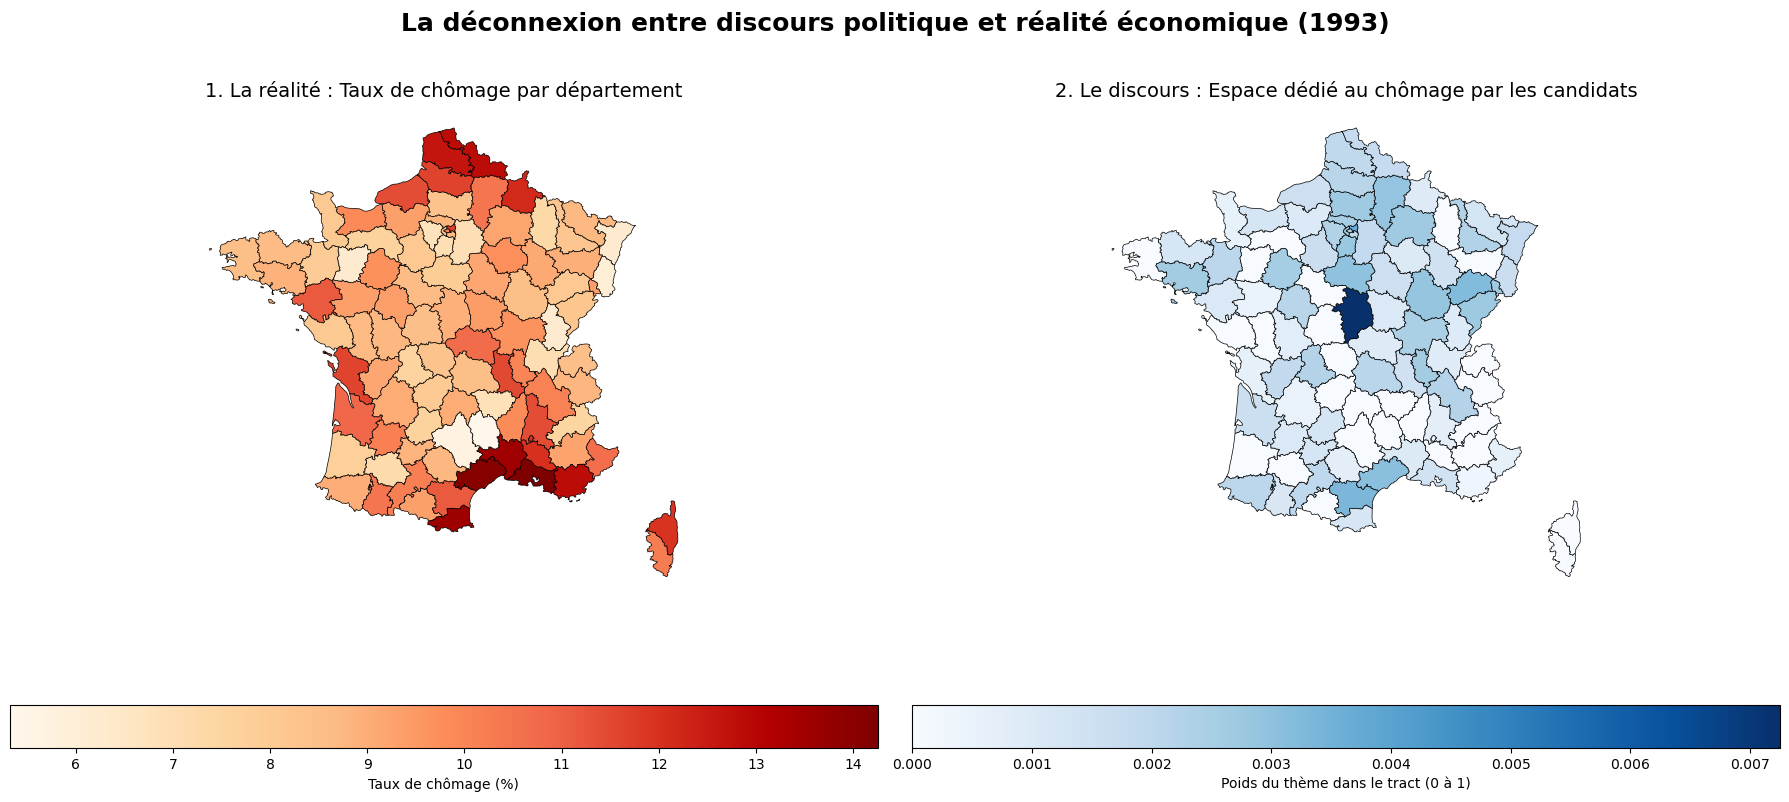

In [41]:
import geopandas as gpd
import matplotlib.pyplot as plt

print("Téléchargement du fond de carte de la France...")
# Lien public vers un fichier GeoJSON officiel et allégé des départements français
url_geojson = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements-version-simplifiee.geojson"
carte_france = gpd.read_file(url_geojson)

# 1. On renomme la colonne du GeoJSON pour qu'elle corresponde à notre tableau
carte_france = carte_france.rename(columns={'code': 'code_departement'})

# 2. La fusion spatiale : on accroche nos données au fond de carte !
carte_data = carte_france.merge(df_final, on='code_departement', how='left')

# 3. Paramétrage du dessin (2 cartes côte à côte)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("La déconnexion entre discours politique et réalité économique (1993)", fontsize=18, fontweight='bold', y=1.02)

# --- CARTE 1 : La Réalité (INSEE) ---
# On utilise un dégradé rouge (OrRd) pour symboliser la gravité du chômage
carte_data.plot(
    column='taux_chomage_1993', 
    cmap='OrRd', 
    linewidth=0.5, 
    ax=axes[0], 
    edgecolor='black', 
    legend=True,
    legend_kwds={'label': "Taux de chômage (%)", 'orientation': "horizontal"},
    missing_kwds={'color': 'lightgrey', 'label': 'Données manquantes'}
)
axes[0].set_title('1. La réalité : Taux de chômage par département', fontsize=14)
axes[0].axis('off') # On cache les coordonnées GPS (axes X et Y)

# --- CARTE 2 : Le Discours (BERTopic) ---
# On utilise un dégradé bleu (Blues) pour le discours politique
carte_data.plot(
    column='moyenne_discours_chomage', 
    cmap='Blues', 
    linewidth=0.5, 
    ax=axes[1], 
    edgecolor='black', 
    legend=True,
    legend_kwds={'label': "Poids du thème dans le tract (0 à 1)", 'orientation': "horizontal"},
    missing_kwds={'color': 'lightgrey'}
)
axes[1].set_title('2. Le discours : Espace dédié au chômage par les candidats', fontsize=14)
axes[1].axis('off')

# Affichage final
plt.tight_layout()
plt.show()

# Bert augmenté 

In [67]:
import pandas as pd
import torch
from transformers import pipeline
from tqdm import tqdm

# --- CONFIGURATION ---
device = 0 if torch.backends.mps.is_available() else -1
print(f"Calcul sur : {'GPU (Mac MPS)' if device == 0 else 'CPU'}")

# Modèle de classification Zero-Shot (comprend le sens, pas juste les mots)
classifier = pipeline("zero-shot-classification", 
                      model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
                      device=device)

# --- PRÉPARATION DES TEXTES ---
# On regroupe les paragraphes par document (on prend les 500 premiers mots pour la vitesse)
df_docs = df_para.groupby('filename')['paragraphe_brut'].apply(lambda x: " ".join(list(x))[:1500]).reset_index()

# --- LA BOUCLE INTELLIGENTE ---
labels_politiques = ["politique de gauche", "politique de droite"]
labels_themes = ["chômage", "autres sujets"]

resultats = []
print(f"Analyse de {len(df_docs)} documents en cours...")

for text in tqdm(df_docs['paragraphe_brut']):
    if len(text.strip()) < 50:
        resultats.append({'bord': 'Inconnu', 'score_eco': 0})
        continue

    # 1. Analyse du bord politique
    res_pol = classifier(text, labels_politiques, hypothesis_template="Ce texte exprime une {}.")
    bord = "Gauche" if "gauche" in res_pol['labels'][0] else "Droite"
    confiance_pol = res_pol['scores'][0]

    # 2. Analyse de l'intensité économique (Score de 0 à 1)
    res_eco = classifier(text, labels_themes, hypothesis_template="Ce texte traite de {}.")
    # On récupère spécifiquement le score du label "chômage..."
    idx_eco = res_eco['labels'].index("chômage")
    score_eco = res_eco['scores'][idx_eco]

    resultats.append({
        'bord_bert': bord if confiance_pol > 0.6 else "Inconnu", 
        'score_chomage_bert': score_eco
    })

# --- FUSION DES RÉSULTATS ---
df_bert = pd.concat([df_docs, pd.DataFrame(resultats)], axis=1)
df_bert['code_departement'] = df_bert['filename'].str.split('_').str[4].str.lstrip('0')

Calcul sur : GPU (Mac MPS)


Device set to use mps:0


Analyse de 5936 documents en cours...


100%|██████████| 5936/5936 [1:25:31<00:00,  1.16it/s]   


In [73]:
# 1. On calcule la moyenne du score BERT par département
# reset_index() est important pour que 'code_departement' redevienne une colonne et non l'index
df_dept_moyenne = df_bert.groupby('code_departement')['score_chomage_bert'].mean().reset_index()

# 2. Optionnel : On peut aussi compter combien de candidats on a par département
# (Utile pour savoir si notre moyenne est solide ou basée sur 1 seul texte)
df_counts = df_bert.groupby('code_departement')['filename'].count().reset_index().rename(columns={'filename': 'nb_candidats'})

# 3. Fusion de la moyenne et du compte
df_dept_final = pd.merge(df_dept_moyenne, df_counts, on='code_departement')

print("--- APERÇU DES SCORES PAR DÉPARTEMENT ---")
print(df_dept_final.sort_values(by='score_chomage_bert', ascending=False).head(50))

--- APERÇU DES SCORES PAR DÉPARTEMENT ---
   code_departement  score_chomage_bert  nb_candidats
2                11            0.620815            32
12               21            0.596650            49
41               46            0.591392            24
46               50            0.591227            50
78                8            0.585049            32
81               82            0.579950            24
90               90            0.575475            22
35               40            0.573218            25
8                17            0.572822            48
69               71            0.567354            51
9                18            0.564884            32
48               52            0.558400            21
85               86            0.554654            37
34                4            0.554615            17
42               47            0.554397            29
75               77            0.554060            93
56                6            0.550565 

In [100]:
# On part du principe que ton tableau INSEE s'appelle df_insee_1993
# et qu'il contient 'code_departement' et 'taux_chomage_1993'

df_global = pd.merge(
    df_dept_final, 
    df_final[['code_departement', 'taux_chomage_1993']], 
    on='code_departement', 
    how='inner'
)

print(f"\n✅ Fusion réussie ! Nous avons {len(df_global)} départements complets.")

KeyError: "['taux_chomage_1993'] not in index"

In [79]:
df_global.head()

,code_departement,score_chomage_bert,nb_candidats,taux_chomage_1993
0,1,0.540209,34,7.025
1,10,0.453693,30,9.750
2,11,0.620815,32,11.125
3,12,0.460209,22,5.700
4,13,0.505078,179,14.250


In [80]:
correlation = df_global['score_chomage_bert'].corr(df_global['taux_chomage_1993'])

print("\n" + "="*55)
print(f"🎯 Coefficient de corrélation (Pearson) : {correlation:.3f}")
print("="*55)


🎯 Coefficient de corrélation (Pearson) : -0.044


In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

print("Téléchargement du fond de carte de la France...")
# Lien public vers un fichier GeoJSON officiel et allégé des départements français
url_geojson = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements-version-simplifiee.geojson"
carte_france = gpd.read_file(url_geojson)

# 1. On renomme la colonne du GeoJSON pour qu'elle corresponde à notre tableau
carte_france = carte_france.rename(columns={'code': 'code_departement'})

# 2. La fusion spatiale : on accroche nos données au fond de carte !
carte_data = carte_france.merge(df_global, on='code_departement', how='left')

# 3. Paramétrage du dessin (2 cartes côte à côte)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("La déconnexion entre discours politique et réalité économique (1993)", fontsize=18, fontweight='bold', y=1.02)

# --- CARTE 1 : La Réalité (INSEE) ---
# On utilise un dégradé rouge (OrRd) pour symboliser la gravité du chômage
carte_data.plot(
    column='taux_chomage_1988', 
    cmap='OrRd', 
    linewidth=0.5, 
    ax=axes[0], 
    edgecolor='black', 
    legend=True,
    legend_kwds={'label': "Taux de chômage (%)", 'orientation': "horizontal"},
    missing_kwds={'color': 'lightgrey', 'label': 'Données manquantes'}
)
axes[0].set_title('1. La réalité : Taux de chômage par département', fontsize=14)
axes[0].axis('off') # On cache les coordonnées GPS (axes X et Y)

# --- CARTE 2 : Le Discours (BERTopic) ---
# On utilise un dégradé bleu (Blues) pour le discours politique
carte_data.plot(
    column='score_chomage_bert', 
    cmap='Blues', 
    linewidth=0.5, 
    ax=axes[1], 
    edgecolor='black', 
    legend=True,
    legend_kwds={'label': "Poids du thème dans le tract (0 à 1)", 'orientation': "horizontal"},
    missing_kwds={'color': 'lightgrey'}
)
axes[1].set_title('2. Le discours : Espace dédié au chômage par les candidats', fontsize=14)
axes[1].axis('off')

# Affichage final
plt.tight_layout()
plt.show()

# Données de 1988 


In [84]:
# Path 
path = Path("../data/raw/text_files/1988/legislatives")
documents = []

# To get all .txt files in the folder and read their content
for file in path.glob("*.txt"):
    try:
        texte = file.read_text(encoding='utf-8', errors='ignore')
        documents.append({
            "filename": file.name,
            "texte_brut": texte})
    except Exception as e:
        print(f"Error with {file.name} : {e}")


df = pd.DataFrame(documents)
print(f"{len(df)} documents in the dataframe")

3628 documents in the dataframe


In [85]:
import pandas as pd

print(f"Tableau d'origine : {len(df)} documents complets.")

# 1. Découpage par sauts de ligne
# On utilise une expression régulière (r'\n+') pour couper le texte à chaque fois 
# qu'il y a un ou plusieurs sauts de ligne. Cela crée une liste de paragraphes.
df['liste_paragraphes'] = df['texte_brut'].str.split(r'\n+')

# 2. L'explosion du DataFrame (La magie de Pandas)
# La fonction explode() va prendre chaque paragraphe de la liste et créer une 
# nouvelle ligne dans le tableau, tout en dupliquant le 'filename' correspondant !
df_para = df.explode('liste_paragraphes').reset_index(drop=True)

# 3. On renomme la colonne pour que ce soit propre
df_para = df_para.rename(columns={'liste_paragraphes': 'paragraphe_brut'})

# 4. Le filtre anti-bruit (Crucial pour l'OCR)
# L'OCR génère souvent des "paragraphes" qui ne sont qu'un chiffre, un tiret 
# ou un mot coupé. On va éliminer tous les paragraphes de moins de 50 caractères.
df_para['paragraphe_brut'] = df_para['paragraphe_brut'].astype(str) # Sécurité
df_para = df_para[df_para['paragraphe_brut'].str.len() > 50].reset_index(drop=True)

print(f"Nouveau tableau : {len(df_para)} paragraphes robustes extraits !")
print("\n--- Aperçu des premiers paragraphes du premier fichier ---")
print(df_para[['filename', 'paragraphe_brut']].head(3))

Tableau d'origine : 3628 documents complets.
Nouveau tableau : 68128 paragraphes robustes extraits !

--- Aperçu des premiers paragraphes du premier fichier ---
                             filename  \
0  EL175_L_1988_06_037_03_1_PF_03.txt   
1  EL175_L_1988_06_037_03_1_PF_03.txt   
2  EL175_L_1988_06_037_03_1_PF_03.txt   

                                     paragraphe_brut  
0  MAJORITE PRESIDENTIELLE POUR LA FRANCE UNIE EL...  
1  Le 8 mai, avec 59,2 % des voix, les femmes et ...  
2  Dès le 10 mai, Michel ROCARD, Premier ministre...  


In [86]:
import pandas as pd
import torch
from transformers import pipeline
from tqdm import tqdm

# --- CONFIGURATION ---
device = 0 if torch.backends.mps.is_available() else -1
print(f"Calcul sur : {'GPU (Mac MPS)' if device == 0 else 'CPU'}")

# Modèle de classification Zero-Shot (comprend le sens, pas juste les mots)
classifier = pipeline("zero-shot-classification", 
                      model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
                      device=device)

# --- PRÉPARATION DES TEXTES ---
# On regroupe les paragraphes par document (on prend les 500 premiers mots pour la vitesse)
df_docs = df_para.groupby('filename')['paragraphe_brut'].apply(lambda x: " ".join(list(x))[:1500]).reset_index()

# --- LA BOUCLE INTELLIGENTE ---
labels_politiques = ["politique de gauche", "politique de droite"]
labels_themes = ["chômage", "autres sujets"]

resultats = []
print(f"Analyse de {len(df_docs)} documents en cours...")

for text in tqdm(df_docs['paragraphe_brut']):
    if len(text.strip()) < 50:
        resultats.append({'bord': 'Inconnu', 'score_eco': 0})
        continue

    # 1. Analyse du bord politique
    res_pol = classifier(text, labels_politiques, hypothesis_template="Ce texte exprime une {}.")
    bord = "Gauche" if "gauche" in res_pol['labels'][0] else "Droite"
    confiance_pol = res_pol['scores'][0]

    # 2. Analyse de l'intensité économique (Score de 0 à 1)
    res_eco = classifier(text, labels_themes, hypothesis_template="Ce texte traite de {}.")
    # On récupère spécifiquement le score du label "chômage..."
    idx_eco = res_eco['labels'].index("chômage")
    score_eco = res_eco['scores'][idx_eco]

    resultats.append({
        'bord_bert': bord if confiance_pol > 0.6 else "Inconnu", 
        'score_chomage_bert': score_eco
    })

# --- FUSION DES RÉSULTATS ---
df_bert = pd.concat([df_docs, pd.DataFrame(resultats)], axis=1)
df_bert['code_departement'] = df_bert['filename'].str.split('_').str[4].str.lstrip('0')

'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: 69f94bda-bb68-4aa6-bca5-6f944d97b591)')' thrown while requesting HEAD https://huggingface.co/MoritzLaurer/mDeBERTa-v3-base-mnli-xnli/resolve/main/config.json
Retrying in 1s [Retry 1/5].


Calcul sur : GPU (Mac MPS)


Device set to use mps:0


Analyse de 3620 documents en cours...


100%|██████████| 3620/3620 [39:22<00:00,  1.53it/s]  


In [87]:
# 1. On calcule la moyenne du score BERT par département
# reset_index() est important pour que 'code_departement' redevienne une colonne et non l'index
df_dept_moyenne = df_bert.groupby('code_departement')['score_chomage_bert'].mean().reset_index()

# 2. Optionnel : On peut aussi compter combien de candidats on a par département
# (Utile pour savoir si notre moyenne est solide ou basée sur 1 seul texte)
df_counts = df_bert.groupby('code_departement')['filename'].count().reset_index().rename(columns={'filename': 'nb_candidats'})

# 3. Fusion de la moyenne et du compte
df_dept_final = pd.merge(df_dept_moyenne, df_counts, on='code_departement')

print("--- APERÇU DES SCORES PAR DÉPARTEMENT ---")
print(df_dept_final.sort_values(by='score_chomage_bert', ascending=False).head(50))

--- APERÇU DES SCORES PAR DÉPARTEMENT ---
   code_departement  score_chomage_bert  nb_candidats
99              986            0.834542             1
35               40            0.578274            16
85               86            0.561231            26
0                 1            0.556213            24
26               32            0.537440             7
70               72            0.527428            31
83               84            0.527284            27
71               73            0.500410            16
11                2            0.496095            30
22               2B            0.494873            15
62               65            0.490054            20
38               43            0.483537             9
14               23            0.475378            14
41               46            0.475312            11
54               58            0.473039            15
2                11            0.472774            16
47               51            0.464294 

In [90]:
df_insee = pd.read_excel('../data/external/sl_etc_2025T4.xls') 

# 2. Création du Taux 1993 (Moyenne des 4 trimestres)
df_insee['taux_chomage_1988'] = df_insee[['T1_1993', 'T2_1993', 'T3_1993', 'T4_1993']].mean(axis=1)


# 3. Nettoyage de la clé de jointure (Le plus important !)
# On force en texte
df_insee['code_departement'] = df_insee['Code'].astype(str)

# Sécurité 1 : Si Excel a transformé "1" en "1.0", on enlève le ".0"
df_insee['code_departement'] = df_insee['code_departement'].str.replace('.0', '', regex=False)

# Sécurité 2 : On remet les zéros au début pour les départements 1 à 9 (ex: "1" devient "01")
df_insee['code_departement'] = df_insee['code_departement'].apply(lambda x: x.zfill(2) if len(str(x)) == 1 else x)



In [91]:
# On part du principe que ton tableau INSEE s'appelle df_insee_1993
# et qu'il contient 'code_departement' et 'taux_chomage_1993'

df_global = pd.merge(
    df_dept_final, 
    df_insee[['code_departement', 'taux_chomage_1988']], 
    on='code_departement', 
    how='inner'
)

print(f"\n✅ Fusion réussie ! Nous avons {len(df_global)} départements complets.")


✅ Fusion réussie ! Nous avons 89 départements complets.


In [95]:
print(df_global.head(30))

   code_departement  score_chomage_bert  nb_candidats  taux_chomage_1988
0                10            0.376820            24              9.750
1                11            0.472774            16             11.125
2                12            0.294835            11              5.700
3                13            0.421907           117             14.250
4                14            0.429521            41              9.875
5                15            0.461229            11              9.025
6                16            0.424502            23              9.175
7                17            0.292556            29             11.575
8                18            0.264228            19              8.950
9                19            0.291268            16              8.025
10               21            0.363567            37              8.500
11               22            0.414761            31              8.625
12               23            0.475378            

In [93]:
correlation = df_global['score_chomage_bert'].corr(df_global['taux_chomage_1988'])

print("\n" + "="*55)
print(f"🎯 Coefficient de corrélation (Pearson) : {correlation:.3f}")
print("="*55)


🎯 Coefficient de corrélation (Pearson) : 0.034


In [98]:
df_global.head()

,code_departement,score_chomage_bert,nb_candidats,taux_chomage_1988
0,10,0.376820,24,9.750
1,11,0.472774,16,11.125
2,12,0.294835,11,5.700
3,13,0.421907,117,14.250
4,14,0.429521,41,9.875


Téléchargement du fond de carte de la France...


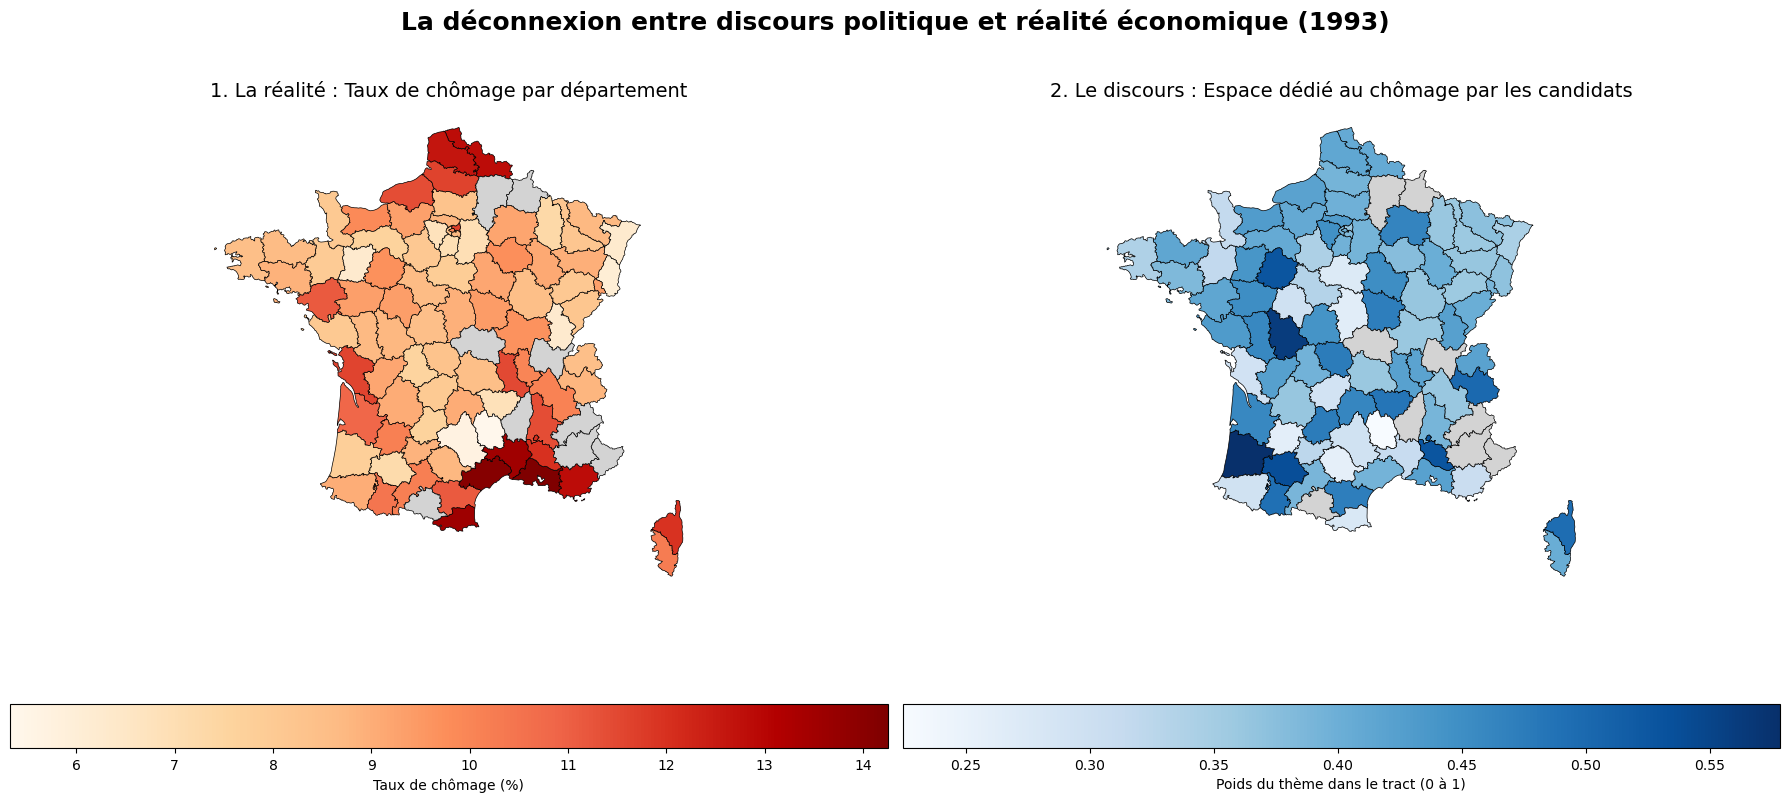

In [99]:
import geopandas as gpd
import matplotlib.pyplot as plt

print("Téléchargement du fond de carte de la France...")
# Lien public vers un fichier GeoJSON officiel et allégé des départements français
url_geojson = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements-version-simplifiee.geojson"
carte_france = gpd.read_file(url_geojson)

# 1. On renomme la colonne du GeoJSON pour qu'elle corresponde à notre tableau
carte_france = carte_france.rename(columns={'code': 'code_departement'})

# 2. La fusion spatiale : on accroche nos données au fond de carte !
carte_data = carte_france.merge(df_global, on='code_departement', how='left')

# 3. Paramétrage du dessin (2 cartes côte à côte)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("La déconnexion entre discours politique et réalité économique (1993)", fontsize=18, fontweight='bold', y=1.02)

# --- CARTE 1 : La Réalité (INSEE) ---
# On utilise un dégradé rouge (OrRd) pour symboliser la gravité du chômage
carte_data.plot(
    column='taux_chomage_1988', 
    cmap='OrRd', 
    linewidth=0.5, 
    ax=axes[0], 
    edgecolor='black', 
    legend=True,
    legend_kwds={'label': "Taux de chômage (%)", 'orientation': "horizontal"},
    missing_kwds={'color': 'lightgrey', 'label': 'Données manquantes'}
)
axes[0].set_title('1. La réalité : Taux de chômage par département', fontsize=14)
axes[0].axis('off') # On cache les coordonnées GPS (axes X et Y)

# --- CARTE 2 : Le Discours (BERTopic) ---
# On utilise un dégradé bleu (Blues) pour le discours politique
carte_data.plot(
    column='score_chomage_bert', 
    cmap='Blues', 
    linewidth=0.5, 
    ax=axes[1], 
    edgecolor='black', 
    legend=True,
    legend_kwds={'label': "Poids du thème dans le tract (0 à 1)", 'orientation': "horizontal"},
    missing_kwds={'color': 'lightgrey'}
)
axes[1].set_title('2. Le discours : Espace dédié au chômage par les candidats', fontsize=14)
axes[1].axis('off')

# Affichage final
plt.tight_layout()
plt.show()